In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#used for loading dataset

from datasets import load_dataset


now we'll load the dataset from hugging face

In [ ]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

In [ ]:
label_names = emotion_dataset['train'].features['label'].names

In [ ]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [ ]:
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)


In [ ]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [ ]:
df_train.isnull().sum()

,0
text,0
label,0


**EDA**

In [ ]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

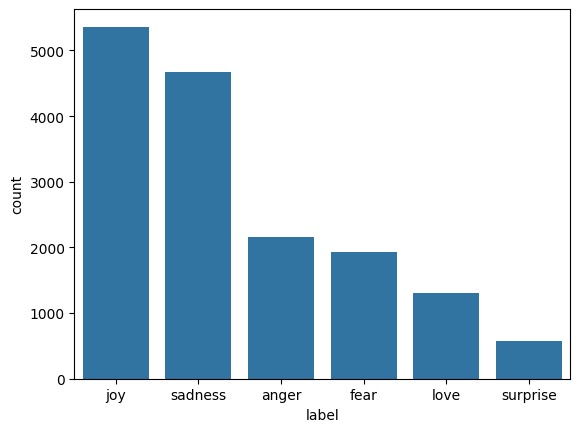

In [ ]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

In [ ]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


**Data Preprocessing using NLP**

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


**Shared Training Utilities**

In [ ]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Phase 1 Plain Foundational Models

Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

Phase 2---- Simple RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.1485 - loss: 2.0443 - val_accuracy: 0.3300 - val_loss: 1.7845
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.1482 - loss: 1.8751 - val_accuracy: 0.2770 - val_loss: 1.7470
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.1306 - loss: 1.8221 - val_accuracy: 0.0455 - val_loss: 1.7871
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.1390 - loss: 1.8076 - val_accuracy: 0.0430 - val_loss: 1.8003
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.1389 - loss: 1.8034 - val_accuracy: 0.1100 - val_loss: 1.8225
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2770 - loss: 1.7470
RNN Loss: 1.7469501495361328
RNN Accuracy: 0.2770000100135803


6.2  Model 2 — Standard LSTM

In [ ]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 48s 90ms/step - accuracy: 0.1452 - loss: 1.7953 - val_accuracy: 0.1145 - val_loss: 1.7849
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 77s 80ms/step - accuracy: 0.1402 - loss: 1.7937 - val_accuracy: 0.3455 - val_loss: 1.7671
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 78ms/step - accuracy: 0.1388 - loss: 1.7933 - val_accuracy: 0.1130 - val_loss: 1.7901
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1145 - loss: 1.7849
LSTM Loss: 1.7849189043045044
LSTM Accuracy: 0.1145000010728836


6.3 Model 3 — Standard GRU

In [ ]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 66ms/step - accuracy: 0.1439 - loss: 1.7977 - val_accuracy: 0.1125 - val_loss: 1.7737
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.1513 - loss: 1.7959 - val_accuracy: 0.0795 - val_loss: 1.7876
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.1520 - loss: 1.7943 - val_accuracy: 0.0340 - val_loss: 1.8016
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1125 - loss: 1.7737
GRU Loss: 1.7737154960632324
GRU Accuracy: 0.11249999701976776


6.4 Phase 1 Ranking & Selection

In [ ]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df


,Model,Test Loss,Test Accuracy
0,RNN,1.746950,0.2770
1,LSTM,1.784919,0.1145
2,GRU,1.773715,0.1125


7. Phase 2 — Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization

7.1 Model 4 — Advanced Stacked Bidirectional GRU

In [ ]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train & Evaluate Advanced Bidirectional GRU

In [ ]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 93s 180ms/step - accuracy: 0.5921 - loss: 1.0310 - val_accuracy: 0.8905 - val_loss: 0.3532
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 109s 218ms/step - accuracy: 0.9158 - loss: 0.2427 - val_accuracy: 0.9165 - val_loss: 0.2142
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 99s 198ms/step - accuracy: 0.9384 - loss: 0.1595 - val_accuracy: 0.9150 - val_loss: 0.2698
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 187ms/step - accuracy: 0.9559 - loss: 0.1075 - val_accuracy: 0.9245 - val_loss: 0.2313
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 185ms/step - accuracy: 0.9657 - loss: 0.0908 - val_accuracy: 0.9220 - val_loss: 0.2405


8. Overall Evaluation & Bias Analysis

8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step


<Axes: >

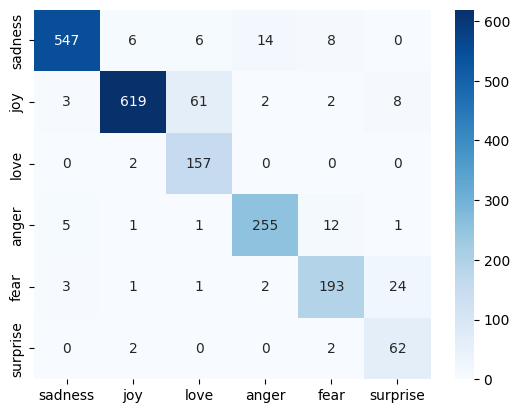

In [ ]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
#

9. Final Predictions

In [ ]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: fear
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


10. Save Model & Tokenizer

In [ ]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)